# <center>Clustering Analysis<center>

<p>Team Name: Team Regular
<p>Student Names: Alameen Adeku, Adam Rodi, Adriean Lemoine, Nicholas Burgo

## Instructions
Use generic coding style unless hard-coded values are really necessary.<br>
Your code must be efficient and use self-explanatory naming.<br>
Use appropriate Python library methods for each task instead of using loops.<br>
Run your entire code and save. Then submit this <b>saved</b> copy.

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os, re
import pandas as pd
from scipy.ndimage import uniform_filter, sobel
import seaborn as sns
import tifffile as tfl

## Configurations

In [2]:
# --- Directory Configs ---

data_dir = os.path.join('..', 'Data')
input_data_dir = os.path.join(data_dir, 'input/zebrafish_tiff_scans')
output_data_dir = os.path.join(data_dir, 'output')
figure_dir = os.path.join(output_data_dir, 'figures')
# Format of data files which prefix the sequential sample number
# Ex: 'ZS-1.tif' would have a data file prefix of 'ZS-'
data_file_prefix = 'ZS-' 

# Names for data group folders
group1_str = 'control'
group2_str = 'anesthetic'
group3_str = 'stimulant'

group1_dir = input_data_dir + '/' + group1_str
group2_dir = input_data_dir + '/' + group2_str
group3_dir = input_data_dir + '/' + group3_str


## Functions

In [3]:
# Functions for loading of initial data

def load_tiff_stacks(directory: str, n: int):
    '''Load tiff stacks as 3D numpy arrays into stack_array.'''
    stack_array = []
    
    for i in range(n):
        stack = tfl.imread(f'{directory}/{data_file_prefix}{i+1}.tif').astype(float)
        stack_array.append(stack)

    return stack_array

def normalize_all_tiff_stacks(tiff_stack_array):
    normalized_tiff_stacks = []
    
    for i in range(len(tiff_stack_array)):
        normalized_tiff_stacks.append(normalize_tiff_stack(tiff_stack_array[i]))

    return normalized_tiff_stacks


def normalize_tiff_stack(tiff_stack):
    '''Normalize tiff stack in range 0-1.'''
    norm_tiff_stack = tiff_stack / tiff_stack.max()
    return norm_tiff_stack 

def get_all_pixel_tables(tif_stack_array):
    pixel_tables = []

    for i in range(len(tif_stack_array)):
        pixel_tables.append(stack_to_pixel_table(tif_stack_array[i]))

    return pixel_tables

def stack_to_pixel_table(tiff_array):
    depth, height, width = tiff_array.shape

    # Create coordinate grid
    z, y, x = np.meshgrid(
        np.arange(depth),
        np.arange(height),
        np.arange(width),
        indexing = 'ij'
    )

    # Flatten to build table
    pixel_table = np.column_stack((
        z.flatten(), # z coordinate
        y.flatten(), # y coordinate
        x.flatten(), # x coordinate
        tiff_array.flatten() # intensity
    ))

    return pixel_table

def stacks_to_dataframe(stacks_2d, group_label):
    '''Convert list of 2D pixel tables to one DataFrame.'''
    df_all = pd.DataFrame()
    
    for i, pixel_table in enumerate(stacks_2d):
        df = pd.DataFrame(pixel_table, columns=['z', 'y', 'x', 'intensity'])
        df[['z', 'y', 'x']] = df[['z', 'y', 'x']].astype(int) 
        df['fish_id'] = i + 1
        df['group'] = group_label
        df_all = pd.concat([df_all, df], ignore_index=True)
        
    return df_all

def build_group_dataframe(directory: str, n: int, group_label='control'):
    # Load stacks
    stacks = load_tiff_stacks(directory, n)
    
    # Normalize stacks
    stacks_norm = normalize_all_tiff_stacks(stacks)
    
    # Convert to 2D pixel tables
    stacks_2d = get_all_pixel_tables(stacks_norm)
    
    # Build a combined singular Pandas DataFrame
    df = stacks_to_dataframe(stacks_2d, group_label)
    
    return df

In [4]:
# Feature helper functions for texture and gradient data generation

def local_std_2d(img2d, k=3):
    """Fast local std using mean and mean-of-squares (reflect padding)."""
    m = uniform_filter(img2d, size=k, mode='reflect')
    m2 = uniform_filter(img2d*img2d, size=k, mode='reflect')
    var = m2 - m*m
    var[var < 0] = 0.0
    return np.sqrt(var).astype(np.float32)

def compute_texture_for_stack(stack3d, k=3):
    """Compute local std per z-slice; returns float32 array same shape as stack3d."""
    depth = stack3d.shape[0]
    tex = np.empty_like(stack3d, dtype=np.float32)
    for z in range(depth):
        tex[z] = local_std_2d(stack3d[z], k=k)
    return tex

def compute_gradient_magnitude_stack(stack3d):
    """Compute Sobel-based 2D gradient magnitude per z-slice."""
    depth = stack3d.shape[0]
    grad = np.empty_like(stack3d, dtype=np.float32)
    for z in range(depth):
        gx = sobel(stack3d[z], axis=1, mode='reflect')  # x-direction
        gy = sobel(stack3d[z], axis=0, mode='reflect')  # y-direction
        grad[z] = np.hypot(gx, gy).astype(np.float32)
    return grad

def stack_to_pixel_table_with_features(tiff_array, texture_array=None, gradient_array=None):
    """Return (pixel_table, colnames). Non-destructive: keeps original stack_to_pixel_table intact."""
    depth, height, width = tiff_array.shape
    z, y, x = np.meshgrid(
        np.arange(depth),
        np.arange(height),
        np.arange(width),
        indexing='ij'
    )
    cols = [z.flatten(), y.flatten(), x.flatten(), tiff_array.flatten()]
    col_names = ['z', 'y', 'x', 'intensity']
    if texture_array is not None:
        cols.append(texture_array.flatten()); col_names.append('texture')
    if gradient_array is not None:
        cols.append(gradient_array.flatten()); col_names.append('gradient')
    pixel_table = np.column_stack(cols)
    return pixel_table, col_names

def build_group_dataframe_with_features(directory: str, n: int, group_label='control', tex_k=3):
    """Load stacks, normalize, compute texture+grad, convert to dataframe with feature columns."""
    stacks = load_tiff_stacks(directory, n)
    stacks_norm = normalize_all_tiff_stacks(stacks)
    # compute features per stack
    texture_stacks = [compute_texture_for_stack(s, k=tex_k) for s in stacks_norm]
    gradient_stacks = [compute_gradient_magnitude_stack(s) for s in stacks_norm]
    # convert each stack into pixel_table with feature columns and then to DataFrame
    df_all = pd.DataFrame()
    for i, s in enumerate(stacks_norm):
        table, colnames = stack_to_pixel_table_with_features(s, texture_stacks[i], gradient_stacks[i])
        df = pd.DataFrame(table, columns=colnames)
        df[['z','y','x']] = df[['z','y','x']].astype(int)
        df['fish_id'] = i + 1
        df['group'] = group_label
        df_all = pd.concat([df_all, df], ignore_index=True)
    return df_all


In [5]:
# Helper functions

def print_df(dataframe, group_label):
    """Print formatted and abbreviated dataframe"""
    print(
        f"=========\n"
        f"Dataframe for group '{group_label}'\n"
        f"Dataframe size: {dataframe.size:,} samples**\n\n"
        f"{dataframe.head()}\n"
        f"...\n...\n...\n"
        f"{dataframe.tail()}\n"
        f"=========\n"
    )


## Read Data

In [6]:
group1_size = 2
group2_size = 2
group3_size = 2

group1_df = build_group_dataframe_with_features(directory=group1_dir, n=group1_size, group_label=group1_str, tex_k=5)
group2_df = build_group_dataframe_with_features(directory=group2_dir, n=group2_size, group_label=group2_str, tex_k=5)
group3_df = build_group_dataframe_with_features(directory=group3_dir, n=group3_size, group_label=group3_str, tex_k=5)


### Individual Data

In [7]:
print_df(group1_df, group1_str)

Dataframe for group 'control'
Dataframe size: 176,160,768 samples**

   z  y  x  intensity   texture  gradient  fish_id    group
0  0  0  0   0.021763  0.002050  0.008287        1  control
1  0  0  1   0.025027  0.002636  0.019236        1  control
2  0  0  2   0.026659  0.002607  0.013171        1  control
3  0  0  3   0.028836  0.002584  0.022313        1  control
4  0  0  4   0.023395  0.002469  0.019004        1  control
...
...
...
           z    y    x  intensity   texture  gradient  fish_id    group
22020091  46  511  507   0.018160  0.001441  0.004601        2  control
22020092  46  511  508   0.020178  0.001478  0.009024        2  control
22020093  46  511  509   0.018967  0.001344  0.013804        2  control
22020094  46  511  510   0.016949  0.001404  0.003424        2  control
22020095  46  511  511   0.017353  0.001304  0.005707        2  control



In [8]:
print_df(group2_df, group2_str)

Dataframe for group 'anesthetic'
Dataframe size: 142,606,336 samples**

   z  y  x  intensity   texture  gradient  fish_id       group
0  0  0  0   0.024174  0.001944  0.005753        1  anesthetic
1  0  0  1   0.021707  0.001851  0.012343        1  anesthetic
2  0  0  2   0.024174  0.001835  0.014668        1  anesthetic
3  0  0  3   0.025160  0.002023  0.006619        1  anesthetic
4  0  0  4   0.025160  0.001740  0.006318        1  anesthetic
...
...
...
           z    y    x  intensity   texture  gradient  fish_id       group
17825787  33  511  507   0.048304  0.005147  0.009307        2  anesthetic
17825788  33  511  508   0.050360  0.004601  0.043628        2  anesthetic
17825789  33  511  509   0.056526  0.004942  0.021607        2  anesthetic
17825790  33  511  510   0.050360  0.004821  0.049353        2  anesthetic
17825791  33  511  511   0.045221  0.004854  0.036770        2  anesthetic



In [9]:
print_df(group3_df, group3_str)

Dataframe for group 'stimulant'
Dataframe size: 239,075,328 samples**

   z  y  x  intensity   texture  gradient  fish_id      group
0  0  0  0   0.013138  0.001451  0.011362        1  stimulant
1  0  0  1   0.016124  0.001345  0.004721        1  stimulant
2  0  0  2   0.013138  0.001283  0.010591        1  stimulant
3  0  0  3   0.014034  0.001222  0.005341        1  stimulant
4  0  0  4   0.013138  0.001155  0.002569        1  stimulant
...
...
...
           z    y    x  intensity   texture  gradient  fish_id      group
29884411  74  511  507   0.028708  0.002929  0.019800        2  stimulant
29884412  74  511  508   0.025718  0.002992  0.011842        2  stimulant
29884413  74  511  509   0.025120  0.002537  0.005674        2  stimulant
29884414  74  511  510   0.027512  0.002335  0.002675        2  stimulant
29884415  74  511  511   0.025120  0.002226  0.006158        2  stimulant



### Combining dataframes into one set of data

In [10]:
dataset_df = pd.concat([group1_df, group2_df, group3_df], ignore_index=True)

In [11]:
print(dataset_df)

           z    y    x  intensity   texture  gradient  fish_id      group
0          0    0    0   0.021763  0.002050  0.008287        1    control
1          0    0    1   0.025027  0.002636  0.019236        1    control
2          0    0    2   0.026659  0.002607  0.013171        1    control
3          0    0    3   0.028836  0.002584  0.022313        1    control
4          0    0    4   0.023395  0.002469  0.019004        1    control
...       ..  ...  ...        ...       ...       ...      ...        ...
69730299  74  511  507   0.028708  0.002929  0.019800        2  stimulant
69730300  74  511  508   0.025718  0.002992  0.011842        2  stimulant
69730301  74  511  509   0.025120  0.002537  0.005674        2  stimulant
69730302  74  511  510   0.027512  0.002335  0.002675        2  stimulant
69730303  74  511  511   0.025120  0.002226  0.006158        2  stimulant

[69730304 rows x 8 columns]


In [ ]:
groups = ['control', 'anesthetic', 'stimulant']

for g in groups:
    print(f"--- First 20 rows of group: {g} ---")
    # Select only the group and take first 20 rows
    print(dataset_df[dataset_df['group'] == g].head(20))

--- First 20 rows of group: control ---
    z  y   x  intensity   texture  gradient  fish_id    group
0   0  0   0   0.021763  0.002050  0.008287        1  control
1   0  0   1   0.025027  0.002636  0.019236        1  control
2   0  0   2   0.026659  0.002607  0.013171        1  control
3   0  0   3   0.028836  0.002584  0.022313        1  control
4   0  0   4   0.023395  0.002469  0.019004        1  control
5   0  0   5   0.021763  0.002198  0.006203        1  control
6   0  0   6   0.023939  0.001821  0.009233        1  control
7   0  0   7   0.023395  0.001686  0.013080        1  control
8   0  0   8   0.025571  0.001869  0.008179        1  control
9   0  0   9   0.024483  0.002109  0.007094        1  control
10  0  0  10   0.028292  0.002458  0.006203        1  control
11  0  0  11   0.023395  0.002221  0.013080        1  control
12  0  0  12   0.027203  0.002178  0.014940        1  control
13  0  0  13   0.025027  0.001827  0.007847        1  control
14  0  0  14   0.023939  0.001

## Visual Exploration of Data

In [13]:
# Create a folder to save figures if it doesn't exist
os.makedirs(figure_dir, exist_ok=True)
print(f"Saving figures to: {figure_dir}")

numeric_cols = ['intensity', 'texture', 'gradient', 'z', 'y', 'x']

#  Dataset is very large (about 700 million sample points). Obtain subset of data for visualization due to memory limitations.
viz_df = dataset_df.sample(50_000, random_state=451) if len(dataset_df) > 50_000 else test_df.copy()

Saving figures to: ../Data/output/figures


### Histograms

Saved: ../Data/output/figures/histograms.png


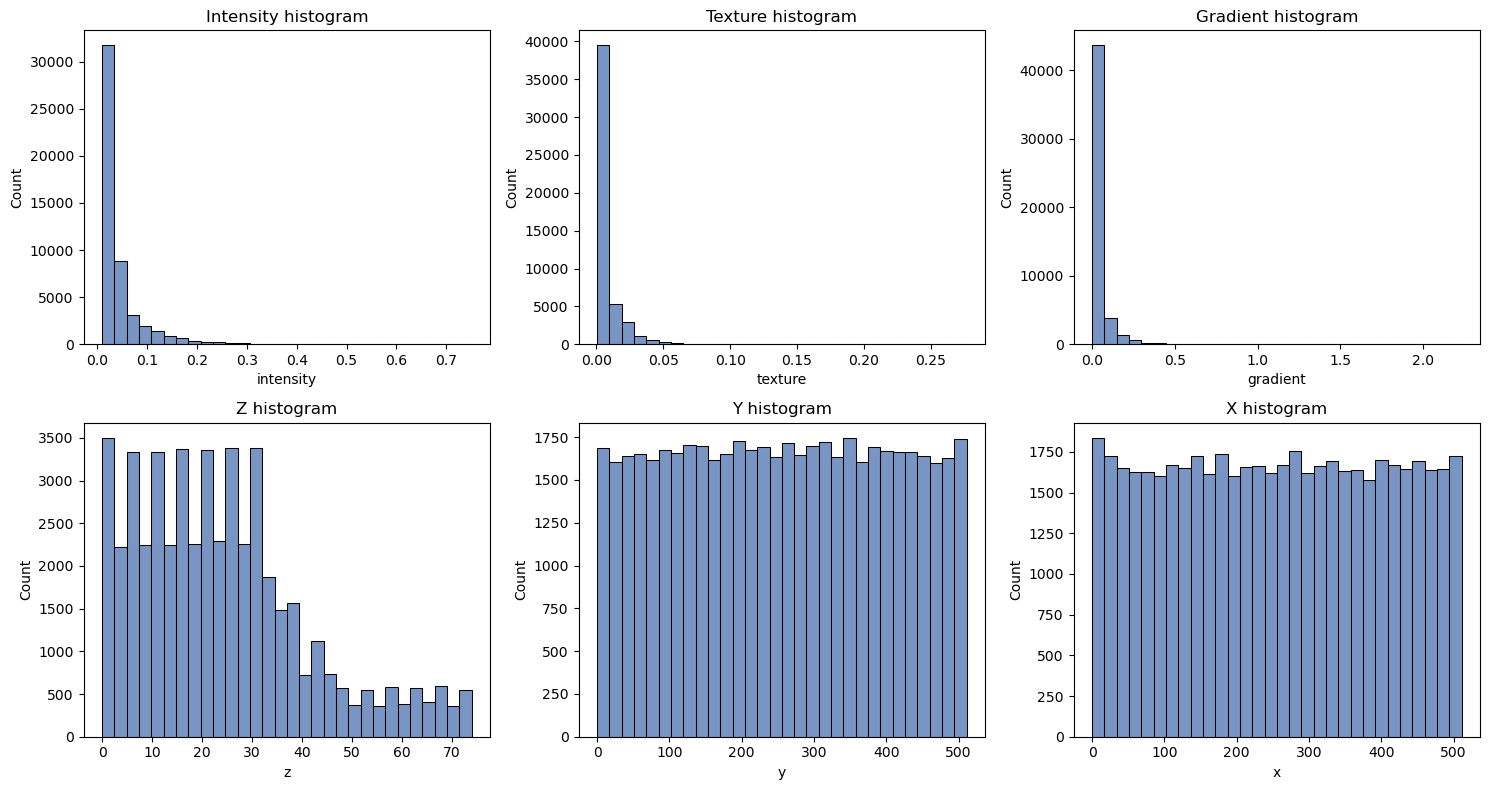

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for col, ax in zip(numeric_cols, axes):
    sns.histplot(viz_df[col], bins=30, ax=ax, color='#4c72b0')
    ax.set_title(f'{col.title()} histogram')
plt.tight_layout()
out_path = os.path.join(figure_dir, 'histograms.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()
plt.close(fig)

### Distributions

Saved: ../Data/output/figures/densities.png


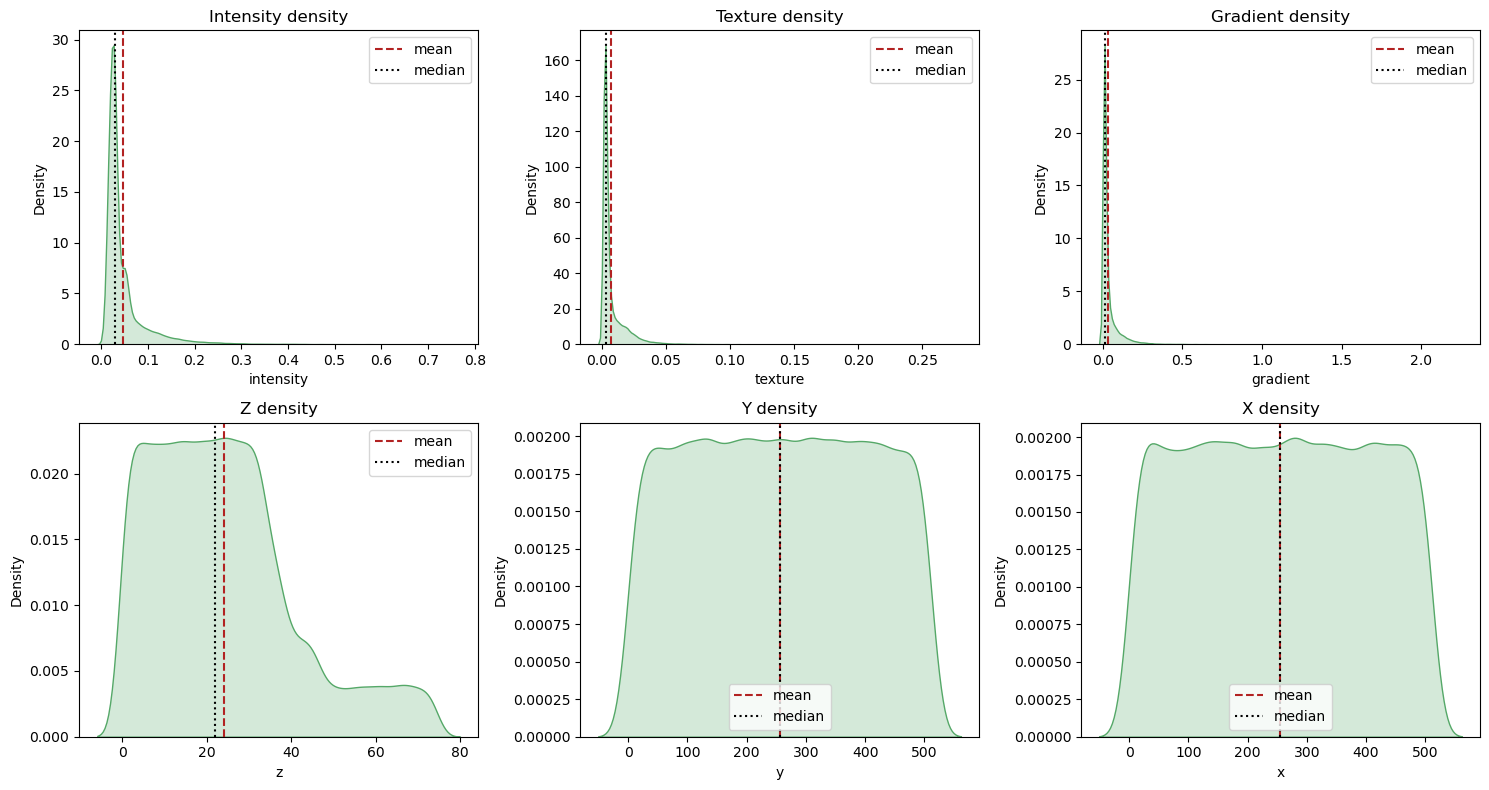

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for col, ax in zip(numeric_cols, axes):
    sns.kdeplot(viz_df[col], fill=True, ax=ax, color='#55a868')
    ax.axvline(viz_df[col].mean(), ls='--', color='firebrick', label='mean')
    ax.axvline(viz_df[col].median(), ls=':', color='black', label='median')
    ax.legend()
    ax.set_title(f'{col.title()} density')
plt.tight_layout()
out_path = os.path.join(figure_dir, 'densities.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()
plt.close(fig)

### Box-Whisker Plots

Saved: ../Data/output/figures/boxplots.png


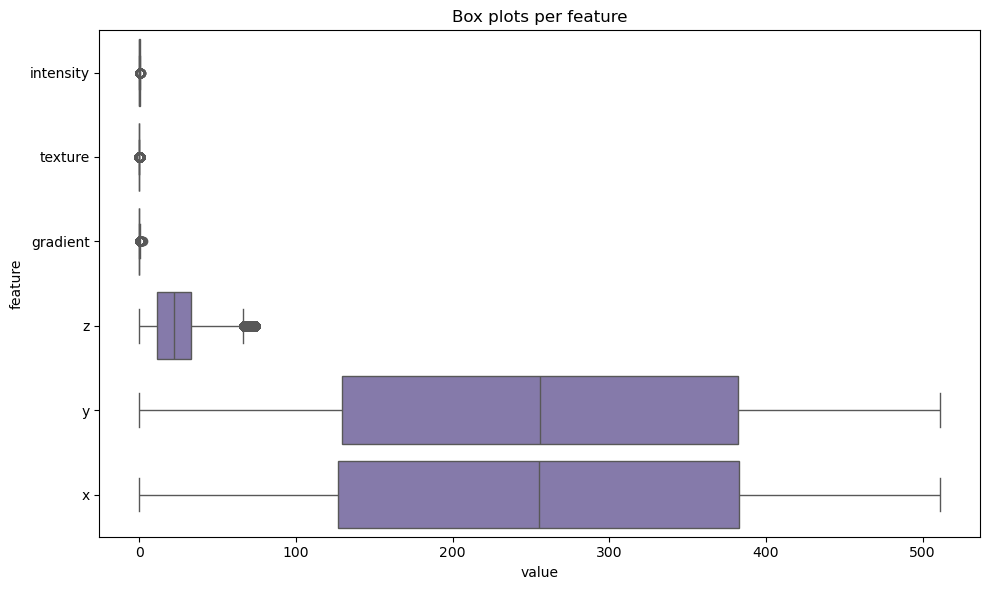

In [16]:
melted = viz_df[numeric_cols].melt(var_name='feature', value_name='value')
plt.figure(figsize=(10, 6))
sns.boxplot(data=melted, x='value', y='feature', orient='h', color='#8172b2')
plt.title('Box plots per feature')
plt.tight_layout()
fig = plt.gcf()
out_path = os.path.join(figure_dir, 'boxplots.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()
plt.close(fig)

### Violin Plots

Saved: ../Data/output/figures/violins.png


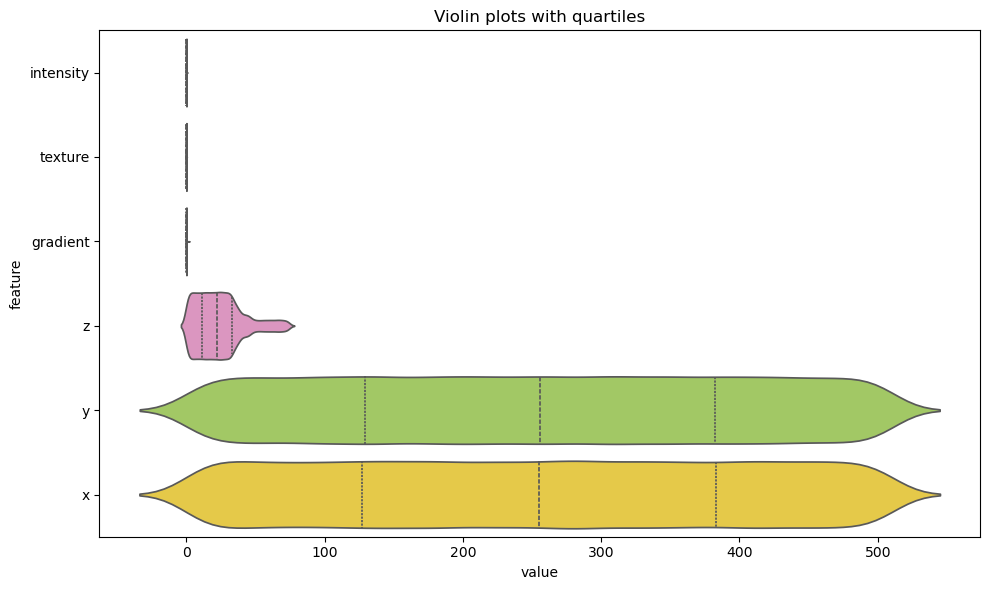

In [17]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=melted,
    x='value', y='feature',
    hue='feature', legend=False,  # fix
    orient='h', inner='quartile',
    palette='Set2'
)
plt.title('Violin plots with quartiles')
plt.tight_layout()
fig = plt.gcf()
out_path = os.path.join(figure_dir, 'violins.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()
plt.close(fig)

### Scatter Plot

Saved: ../Data/output/figures/scatter_plots.png


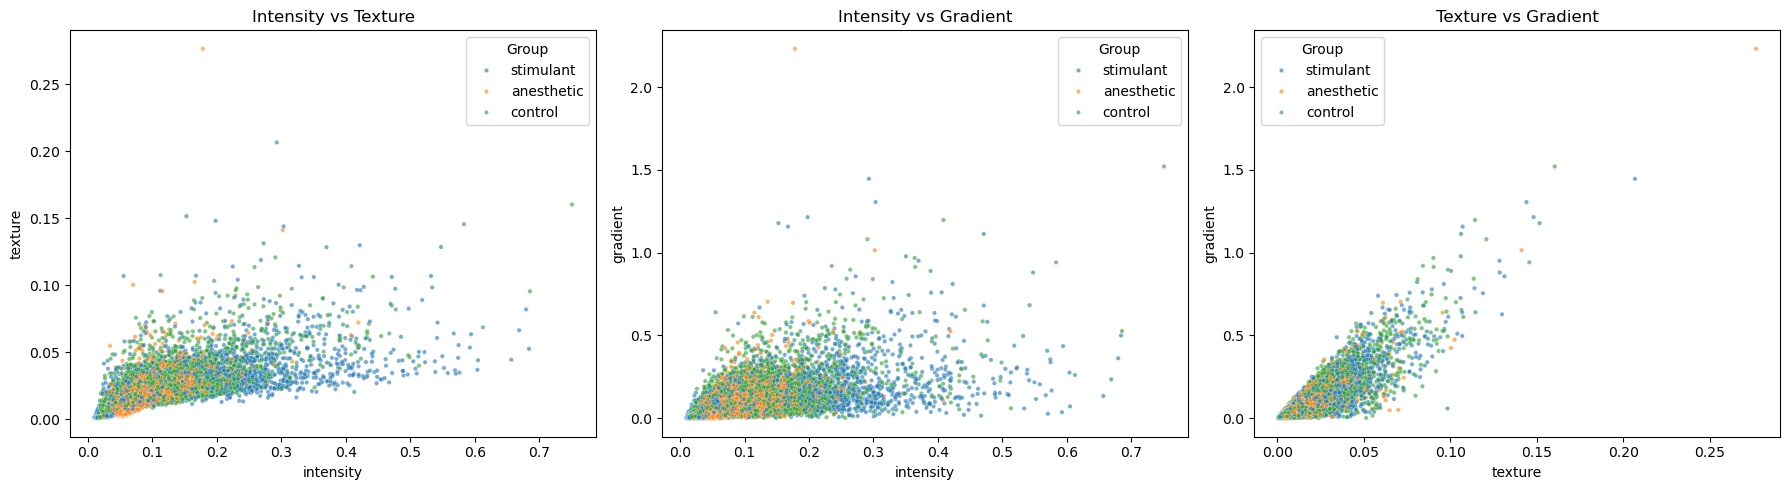

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Example numeric columns to compare
numeric_cols = ['intensity', 'texture', 'gradient']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

pairs = [
    ('intensity', 'texture'),
    ('intensity', 'gradient'),
    ('texture', 'gradient')
]

for (x_col, y_col), ax in zip(pairs, axes):
    sns.scatterplot(
        data=viz_df,
        x=x_col,
        y=y_col,
        hue='group',      # color by experimental group
        alpha=0.6,
        s=10,
        ax=ax
    )
    ax.set_title(f'{x_col.title()} vs {y_col.title()}')
    ax.legend().set_title('Group')

plt.tight_layout()
out_path = os.path.join(figure_dir, 'scatter_plots.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()
plt.close(fig)


## Data Quality & Cleaning

Instruction: Add a comment for each method

## Handling Redundancy

### X-square Test

### Correlation Analysis

### Visual Exploration (scatter-plot matrix)

## Dimensionality Reduction

### PCA

## Discretization

### Histogram of Discretized Attribute

### X-square Test of Discretized Attributes

### Visual Exploration (scatter-plot matrix) of Discretized Attributes

## Feature Selection/Generation

### Select Features

### Generate Features

# Generate Clusters

## K-means

## Hierarchical

# Evaluation of Clusters

See instructions provided in the report template

## <center> REFERENCES </center>
List resources (book, internet page, etc.) that you used to complete this challenge.